# Scattering Cross Section of Argon Ion with a Water Molecule

Consider anargon ion of charge $q_{Ar}=+1$, released with initial velocity $\overrightarrow{v_i}=(v,0,0)$ from the position $\overrightarrow{r_i}=(-50,y_0,z_0)$.

It moves towards a water molecule with the position of the first hydrogen atom with mass $m_H$ at $(1,0,0)$, second hydrogen atom at $(-\frac{1}{2},\frac{\sqrt{3}}{2},0)$, and oxygen atom with mass $m_O$ at $(0,0,0)$. At each iteration in the scattering simulation, the orientation (the position of the constituent atoms) changes along three Euler angles. The change in rotation can be described as the action of rotation matrix on the position vector of the atom (with respect to the origin/position of the oxygen atom).

\begin{align*}
  R = R_z(\gamma) \, R_y(\beta) \, R_x(\alpha) &= \begin{bmatrix}
    \cos \gamma & -\sin \gamma & 0 \\
    \sin \gamma &  \cos \gamma & 0 \\
     0          &   0          & 1 \\
  \end{bmatrix}\begin{bmatrix}
    \cos \beta & 0 & \sin \beta \\
     0         & 1 &  0 \\
   -\sin \beta & 0 & \cos \beta \\
  \end{bmatrix}\begin{bmatrix}
    1 &  0          &   0 \\
    0 & \cos \alpha & -\sin \alpha \\
    0 & \sin \alpha &  \cos \alpha \\
  \end{bmatrix} \\
\end{align*}



The O-H bond is assumed to act like a spring with spring constant $k_{1}$ with equilbrium length $r_{OH}=1 Angstrom = 0.1 nm$. 
The H-O-H bond angle is assumed to be maintained at equilibrium value $\theta_{HOH} = 120^\circ$ by a spring with spring constant $k_{2}$ connecting the two hydrogen atoms with equilibrium length of $r_{HH}=\sqrt{3}\approx 0.173 Angstrom = 0.173 Angstrom$. 
Given electrostatic interaction between the hydrogen and oxygen atoms with the argon ion, the O-H bond will stretch or compress, and the restoring force due to the action of the spring is

$$\overrightarrow{F_{H_1}}=-k_1\left(\overrightarrow{r_{H_1}}-\overrightarrow{r_{O}}-\frac{\overrightarrow{r_{H_1}}-\overrightarrow{r_{O}}}{|\overrightarrow{r_{H_1}}-\overrightarrow{r_{O}}|}r_{OH}\right)-k_2\left(\overrightarrow{r_{H_1}}-\overrightarrow{r_{H_2}}-\frac{\overrightarrow{r_{H_1}}-\overrightarrow{r_{H_2}}}{|\overrightarrow{r_{H_1}}-\overrightarrow{r_{H_2}}|}r_{HH}\right)$$

$$\overrightarrow{F_{H_2}}=-k_1\left(\overrightarrow{r_{H_2}}-\overrightarrow{r_{O}}-\frac{\overrightarrow{r_{H_2}}-\overrightarrow{r_{O}}}{|\overrightarrow{r_{H_2}}-\overrightarrow{r_{O}}|}r_{OH}\right)-k_2\left(\overrightarrow{r_{H_2}}-\overrightarrow{r_{H_1}}-\frac{\overrightarrow{r_{H_2}}-\overrightarrow{r_{H_1}}}{|\overrightarrow{r_{H_2}}-\overrightarrow{r_{H_1}}|}r_{HH}\right)$$

$$\overrightarrow{F_O}=-k_1\left(\overrightarrow{r_{O}}-\overrightarrow{r_{H_1}}-\frac{\overrightarrow{r_{O}}-\overrightarrow{r_{H_1}}}{|\overrightarrow{r_{O}}-\overrightarrow{r_{H_1}}|}r_{OH}\right)-k_1\left(\overrightarrow{r_{O}}-\overrightarrow{r_{H_2}}-\frac{\overrightarrow{r_{O}}-\overrightarrow{r_{H_2}}}{|\overrightarrow{r_{O}}-\overrightarrow{r_{H_2}}|}r_{OH}\right)
$$

where $\overrightarrow{F_{H_1}}$, $\overrightarrow{F_{H_2}}$, and $\overrightarrow{F_O}$ are the restoring forces acting on the first and second hydrogen, and the oxygen atom, respectively. 




In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import time

#Adaptive Runge-Kutta to solve ODE
def rungeKutta4StepperError(operator, initCond, time, dt):
    ''' 
    Performs a step composed of 2 RK4 steps an ODE of type dy(t)/dt = f(t,y(t))
    Then performs a single step of RK4 and uses the different solutions to estimate the error

    Parameters
        ----------
        operator : function
            function of time (: float) and the y (: float / numpy.array)
            NOTICE: it must a function of both variables even if not explicitly dependence on both
            For instance:   lambda t, y: np.sin(y)    and not     lambda y: np.sin(y) 
        initCond : float / numpy.array
            initial condition, i.e. y(t = initial time)
        initTime : float
            initial time
        dt       : float
            delta t of the step (notice that each substep will act at dt/2)

    Returns
        ----------
        solution : numpy.array
            numpy array of the calculated y at the end of the step
        error    : float
            estimation of the error
    '''

    # Performs a RK step for the first half step
    k1A = operator(time, initCond)
    k2A = operator(time + dt/4, initCond + dt * k1A/4 )
    k3A = operator(time + dt/4, initCond + dt * k2A/4 )
    k4A = operator(time + dt/2, initCond + dt * k3A/2)

    yhalf = initCond + dt * (k1A + 2*k2A + 2*k3A + k4A)/12

    # Performs a RK step for the first half step
    k1B = operator(time + dt/2, yhalf)
    k2B = operator(time + 3*dt/4, yhalf + dt * k1B/4 )
    k3B = operator(time + 3*dt/4, yhalf + dt * k2B/4 )
    k4B = operator(time + dt, yhalf + dt * k3B/2)

    ydoublestep = yhalf + dt * (k1B + 2*k2B + 2*k3B + k4B)/12

    # Performs RK4 again but by taking a single large step 
    # Does not recalculate the first k, since it it the same as in the 
    # previous case
    k2 = operator(time + dt/2, initCond + dt * k1A/2 )
    k3 = operator(time + dt/2, initCond + dt * k2/2 )
    k4 = operator(time + dt, initCond + dt * k3)

    ysinglestep = initCond + dt * (k1A + 2*k2 + 2*k3 + k4)/6 

    # calculates the error using the function norm to allow for the use with vectors
    error = np.linalg.norm(ydoublestep-ysinglestep)/16

    return ydoublestep, error

    
def RK4Adaptive(operator, initCond, initTime, finalTime, tolerance, minimumStep):

    maxIncrementOfdt = 3
    tolerance = abs(tolerance)

    # As a first choise of delta t we choose the whole interval
    # We might be lucky and we might be able to calculate directly the 
    # final solution with sufficient precision
    dt = 0.1*(finalTime - initTime)
    reachedEnd = False
    reachedMinimumStep = False
    currentError = 10*tolerance + 1
    times = [initTime]
    solution = [initCond]

    while (not(reachedEnd)):
        newy, error = rungeKutta4StepperError(operator, solution[-1], times[-1], dt)
        if (error <= tolerance or reachedMinimumStep):
            times.append(times[-1]+dt)
            solution.append(newy)
            if (abs(times[-1]-finalTime)<minimumStep): 
                reachedEnd = True
            if (error > 0):
                dt = dt * (tolerance / error)**(0.25)
            else:
                dt = maxIncrementOfdt * dt
            if dt > minimumStep:
                reachedMinimumStep = False
            else:
                dt = minimumStep
            dt = min(dt, finalTime-times[-1])
        else : 
            dt = dt * (tolerance / error)**(0.25)
            if dt < minimumStep:
                dt = minimumStep
                reachedMinimumStep = True

    return np.array(times), np.array(solution)





Assuming purely electrostatic interaction with the hydrogen atoms having a charge of $q_{H_{1}}=q_{H_2}=+1$ and the oxygen atom having a charge of $q_O=-2$, the equation of motion for the argon ion is then

$$\frac{d\overrightarrow{r}}{dt}=\overrightarrow{v}$$

$$\frac{d\overrightarrow{v}}{dt}=\frac{1}{m_{Ar}}\frac{1}{4\pi\epsilon_0}\left[\frac{q_{Ar}q_{H_1}}{|\overrightarrow{r}-\overrightarrow{r_{H_1}}|^3}(\overrightarrow{r}-\overrightarrow{r_{H_1}})+
\frac{q_{Ar}q_{H_2}}{|\overrightarrow{r}-\overrightarrow{r_{H_2}}|^3}(\overrightarrow{r}-\overrightarrow{r_{H_2}})
+\frac{q_{Ar}q_{O}}{|\overrightarrow{r}-\overrightarrow{r_{O}}|^3}(\overrightarrow{r}-\overrightarrow{r_{O}})\right]$$

where $\overrightarrow{r}$ and $\overrightarrow{v}$ are the position and velocity of the argon ion at time $t$, ${m_{Ar}}$ is the mass of the argon ion, $\epsilon_0$ is the vacuum permittivity.

The equation of motions for atoms in the water molecule are then

$$\frac{d\overrightarrow{r_{H_1}}}{dt}=\overrightarrow{v_{H_1}}$$
$$\frac{d\overrightarrow{v_{H_1}}}{dt}=\frac{1}{m_H}\left[-k_1\left(\overrightarrow{r_{H_1}}-\overrightarrow{r_{O}}-\frac{\overrightarrow{r_{H_1}}-\overrightarrow{r_{O}}}{|\overrightarrow{r_{H_1}}-\overrightarrow{r_{O}}|}r_{OH}\right)-k_2\left(\overrightarrow{r_{H_1}}-\overrightarrow{r_{H_2}}-\frac{\overrightarrow{r_{H_1}}-\overrightarrow{r_{H_2}}}{|\overrightarrow{r_{H_1}}-\overrightarrow{r_{H_2}}|}r_{HH}\right)+\frac{1}{4\pi\epsilon_0}\frac{q_{Ar}q_{H_1}}{|\overrightarrow{r_{H_1}}-\overrightarrow{r}|^3}(\overrightarrow{r_{H_1}}-\overrightarrow{r})\right]$$

$$\frac{d\overrightarrow{r_{H_2}}}{dt}=\overrightarrow{v_{H_2}}$$
$$\frac{d\overrightarrow{v_{H_2}}}{dt}=\frac{1}{m_H}\left[-k_1\left(\overrightarrow{r_{H_2}}-\overrightarrow{r_{O}}-\frac{\overrightarrow{r_{H_2}}-\overrightarrow{r_{O}}}{|\overrightarrow{r_{H_2}}-\overrightarrow{r_{O}}|}r_{OH}\right)-k_2\left(\overrightarrow{r_{H_2}}-\overrightarrow{r_{H_1}}-\frac{\overrightarrow{r_{H_2}}-\overrightarrow{r_{H_1}}}{|\overrightarrow{r_{H_2}}-\overrightarrow{r_{H_1}}|}r_{HH}\right)+\frac{1}{4\pi\epsilon_0}\frac{q_{Ar}q_{H_2}}{|\overrightarrow{r_{H_2}}-\overrightarrow{r}|^3}(\overrightarrow{r_{H_2}}-\overrightarrow{r})\right]$$

$$\frac{d\overrightarrow{r_{O}}}{dt}=\overrightarrow{v_{O}}$$

$$\frac{d\overrightarrow{v_{O}}}{dt}=\frac{1}{m_O}\left[-k_1\left(\overrightarrow{r_{O}}-\overrightarrow{r_{H_1}}-\frac{\overrightarrow{r_{O}}-\overrightarrow{r_{H_1}}}{|\overrightarrow{r_{O}}-\overrightarrow{r_{H_1}}|}r_{OH}\right)-k_1\left(\overrightarrow{r_{O}}-\overrightarrow{r_{H_2}}-\frac{\overrightarrow{r_{O}}-\overrightarrow{r_{H_2}}}{|\overrightarrow{r_{O}}-\overrightarrow{r_{H_2}}|}r_{OH}\right)+\frac{q_{Ar}q_{O}}{|\overrightarrow{r_O}-\overrightarrow{r}|^3}(\overrightarrow{r_O}-\overrightarrow{r})\right] $$


Time elapsed = 1.3609731197357178 s


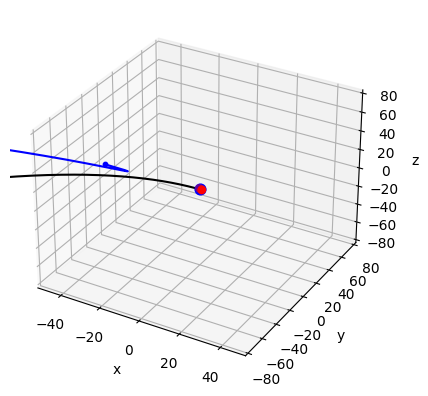

The angle of deflection is 2.1809717613192285 radians, or 124.96047716080533 degrees


In [8]:
#fixed parameters for the water molecule
rHH = np.sqrt(3)    #distance between the two hydrogen atoms
rOH = 1             #distance from the oxygen atom to the hydrogen atom

m_H = 1             #mass of hydrogen atom
m_O = 16            #mass of oxygen atom
k_1 = 1             #spring constant between hydrogen and oxygen atom
k_2 = 1             #spring constant between hydrogen atoms

q_H = 1             #electric charge of hydrogen atom
q_O = -2            #electric charge of oxygen atom

#tunable parameters for the water molecule (orientation)
#initial conditions for water molecule determined by three Euler angles
alpha = 0
beta = 0
gamma = 0

#rotation matrix that allows for different orientation of the water molecule
R_gamma = np.array([[np.cos(gamma), -np.sin(gamma), 0],[np.sin(gamma), np.cos(gamma), 0],[0,0,1]])
R_beta = np.array([[np.cos(beta),0,np.sin(beta)],[0,1,0],[-np.sin(beta),0,np.cos(beta)]])
R_alpha = np.array([[1,0,0],[0,np.cos(alpha),-np.sin(alpha)],[0,np.sin(alpha),np.cos(alpha)]])
rotation = np.linalg.multi_dot([R_gamma,R_beta, R_alpha])

#the initial positions for the first, second hydrogen atom and the oxygen atom
initial_H1 = np.dot(rotation,np.array([1,0,0]))
initial_H2 = np.dot(rotation,np.array([-0.5, np.sqrt(3)/2,0]))
initial_O = np.dot(rotation,np.array([0,0,0]))

#the initial velocity for the first, second hydrogen atom and the oxygen atom
initial_vH1 = np.array([0,0,0])
initial_vH2 = np.array([0,0,0])
initial_vO = np.array([0,0,0])


#==============================================================================================================================


#fixed parameters for the argon ion
m_Ar = 18               #mass of argon ion
epsilon_0 = 8.854E-12   #vacuum permittivity
q_Ar = 1                #electric charge of argon ion

#tunable parameters for argon ion
#initial position of the argon ion
x = -50                 
initial_y = np.random.uniform(-10,10)
initial_z = np.random.uniform(-10,10)
initial_Ar = np.array([x, initial_y, initial_z])

#initial velocity of the argon ion (in the x-direction)
v = 1500                
initial_vAr = np.array([v,0,0])



#==============================================================================================================================
start = time.time()

#solving the ODE with Runge-Kutta 4 method
initial_time  = 0
final_time = 2
tolerance = 0.00000001
step = 0.000001

#the initial condition consists of (3,1) vectors, each specifying the positions/velocities of the atoms
initial_condition = np.array([initial_H1, initial_H2, initial_O,initial_Ar,initial_vH1, initial_vH2, initial_vO, initial_vAr])

#Solution vectors: 
#hence, each solution vector also consists of (3,1) vectors specificying the position/velocity of the atoms
#vec[0] = position of first hydrogen atom
#vec[1] = position of second hydrogen atom
#vec[2] = position of oxygen atom
#vec[3] = position of argon ion

#vec[4] = velocity of first hydrogen atom
#vec[5] = velocity of second hydrogen atom
#vec[6] = velocity of oxygen atom
#vec[7] = velocity of argon ion

operator = lambda t, vec: np.array([
    vec[4],
    vec[5],
    vec[6],
    vec[7],
    (1/m_H)*(-k_1*((vec[0]-vec[2])-rOH*(vec[0]-vec[2])/(np.linalg.norm(vec[0]-vec[2])))
            -k_2*((vec[0]-vec[1])-rHH*(vec[0]-vec[1])/(np.linalg.norm(vec[0]-vec[1]))) 
           +((q_Ar*q_H)/(4*np.pi*epsilon_0*m_Ar))*(vec[3]-vec[0])/(np.linalg.norm(vec[3]-vec[0]))**3 ),
    (1/m_H)*(-k_1*((vec[1]-vec[2])-rOH*(vec[1]-vec[2])/(np.linalg.norm(vec[1]-vec[2])))
            -k_2*((vec[1]-vec[0])-rHH*(vec[1]-vec[0])/(np.linalg.norm(vec[1]-vec[0]))) 
           +((q_Ar*q_H)/(4*np.pi*epsilon_0*m_Ar))*(vec[3]-vec[1])/(np.linalg.norm(vec[3]-vec[1]))**3 ),
    (1/m_O)*(-k_1*((vec[2]-vec[0])-rOH*(vec[2]-vec[0])/(np.linalg.norm(vec[2]-vec[0])))
            -k_1*((vec[2]-vec[1])-rOH*(vec[2]-vec[1])/(np.linalg.norm(vec[2]-vec[1])))
            +((q_Ar*q_O)/(4*np.pi*epsilon_0*m_Ar))*(vec[2]-vec[3])/((np.linalg.norm(vec[2]-vec[3]))**3)),
    (1/(4*np.pi*epsilon_0*m_Ar))*((q_Ar*q_H)*(vec[3]-vec[0])/((np.linalg.norm(vec[3]-vec[0]))**3) 
                                  + (q_Ar*q_H)*(vec[3]-vec[1])/((np.linalg.norm(vec[3]-vec[1]))**3)
                                  +(q_Ar*q_O)*(vec[3]-vec[2])/((np.linalg.norm(vec[3]-vec[2]))**3))
    
])

times, solution = RK4Adaptive(operator, initial_condition, initial_time, final_time, tolerance, step)


end = time.time()
print("Time elapsed = {} s".format(end-start))
#==============================================================================================================================



H1 = solution[:,0]
H2 = solution[:,1]
O = solution[:,2]
COM_water = (m_H*H1+m_H*H2+m_O*O)/(2*m_H+m_O) #position of the center of mass of the water molecule
Ar = solution[:,3]

vH1 = solution[:,4]
vH2 = solution[:,5]
vO = solution[:,6]
vAr = solution[:,7]


fig1 = plt.figure()
ax1 = plt.axes(projection ='3d')

#plot initial position of water molecule
x_H = np.array([initial_H1[0],initial_H2[0]])
y_H = np.array([initial_H1[1],initial_H2[1]])
z_H = np.array([initial_H1[2],initial_H2[2]])
ax1.scatter3D(x_H, y_H, z_H, s=30, color="red")
ax1.scatter3D(initial_O[0],initial_O[1],initial_O[2], s=60, color="blue")

#plot trajectory of the center of mass of water molecule
ax1.plot3D(COM_water[:,0], COM_water[:,1],COM_water[:,2], color="black")
# ax1.plot3D(H1[:,0], H1[:,1],H1[:,2],"--", color="red")
# ax1.plot3D(H2[:,0], H2[:,1],H2[:,2],"--", color="red")
# ax1.plot3D(O[:,0], O[:,1],O[:,2],"--", color="red")

#plot initial position and trajectory of argon ion
ax1.scatter3D(Ar[0,0],Ar[0,1], Ar[0,2], color="blue", s=10)
ax1.plot3D(Ar[:,0],Ar[:,1],Ar[:,2], color="blue")

ax1.set_xlim(x,-x)
ax1.set_ylim(-80,80)
ax1.set_zlim(-80,80)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
plt.show()

#calculate the angular deflection value for this set of initial condition
initial_vel = solution[0,7]
final_vel = solution[-1,7]
initial_mag = np.linalg.norm(initial_vel)
final_mag = np.linalg.norm(final_vel)

deflection = np.arccos(np.dot(initial_vel,final_vel)/(initial_mag*final_mag))
print("The angle of deflection is {} radians, or {} degrees".format(deflection, deflection*(180/np.pi)))  

## Average Angular Deflection of the Argon Ion

Once sufficiently far from the water molecule, the argon ion will have been deflected with final velocity of $\overrightarrow{v}=(v_x,v_y,v_z)$, forming a deflection angle $\phi$ with respect to the initial velocity. The angle can be calculated as follows:

$$\overrightarrow{v_i}\cdot\overrightarrow{v}=|\overrightarrow{v_i}||\overrightarrow{v}|\cos\phi $$

$$\phi=\arccos\left(\frac{\overrightarrow{v_i}\cdot\overrightarrow{v}}{|\overrightarrow{v_i}||\overrightarrow{v}|}\right) $$.

where $\phi$ is the angle between the final velocity vector and the x-axis. The extent of deflection will depend on the initial perpendicular distance of the argon ion to the water molecule, which means that $\phi$ will depend on initial position of the argon ion. Hence, $\overrightarrow{v}$ is a function of $y_0$ and $z_0$.

$$\phi(y_0,z_0)=\arccos\left(\frac{\overrightarrow{v_i}\cdot\overrightarrow{v}(y_0,z_0)}{|\overrightarrow{v_i}||\overrightarrow{v}(y_0,z_0)|}\right) $$.

As $y_0$ and $z_0$ are varied between $-a$ to $a$, and the orientation of the water molecule are varied (the Euler angles $\alpha_0$, $\beta_0$, $\gamma_0$),  $\phi$ will vary.The average angular deflection of the argon ion is calculated as follows:

$$\langle \phi\rangle =\frac{1}{(2a)^2}\int_{-a}^{a}dy \int_{-a}^{a}dz \frac{1}{(2\pi)^3}\int_{-0}^{2\pi}d\alpha \int_{-0}^{2\pi}d\beta \int_{-0}^{2\pi}d\gamma \arccos\left(\frac{\overrightarrow{v_i}\cdot\overrightarrow{v}(y_0,z_0)}{|\overrightarrow{v_i}||\overrightarrow{v}(y_0,z_0)|}\right)$$



In [25]:
#Rectangle Method Integration to find the average angular deflection
#Since it is integration over 5 variables, there will be n^5 points to calculate the integration, 
#and the time taken is very long for large n(number of splits)

def integrationRectangles5D(function, yzmin, yzmax, 
                                theta_min, theta_max,  
                                n_splits_yz, n_splits_theta):
    ''' Calculates the integral of a 2D function by rectangle method '''
    dy = ((yzmax-yzmin)/n_splits_yz)
    dz = ((yzmax-yzmin)/n_splits_yz)
    
    d_alpha = ((theta_max-theta_min)/n_splits_theta)
    d_beta = ((theta_max-theta_min)/n_splits_theta)
    d_gamma = ((theta_max-theta_min)/n_splits_theta)
    
    
    YRectMeth = np.linspace(yzmin, yzmax - dy, n_splits_yz)
    ZRectMeth = np.linspace(yzmin, yzmax - dz, n_splits_yz)
    
    AlphaRect = np.linspace(theta_min, theta_max - d_alpha, n_splits_theta)
    BetaRect = np.linspace(theta_min, theta_max - d_beta, n_splits_theta)
    GammaRect = np.linspace(theta_min, theta_max - d_gamma, n_splits_theta)
    
    YRectMeth, ZRectMeth, AlphaRect, BetaRect, GammaRect = np.meshgrid(YRectMeth, ZRectMeth, AlphaRect, BetaRect, GammaRect)
    
    #The inputs (initial condition for the position and velocity) for the RK4 method are single numbers inputted into (3,1) vectors.
    #Keeping the inputs - all the initial points forming the initial conditions - for the integral 
    #(which uses the RK4 method as the integrated function) as 5D tensor means that it will have to be braodcasted in some way 
    #into the vector, which is impossible.
    #Hence, the inputs - all the initial points forming the initial conditions - for the integral 
    #(which uses the RK4 method as the integrated function) has to be in 1D array, 
    #so the number in each row can be iteratively fed into into the input vectors.
    
    YRectMeth = YRectMeth.flatten()
    ZRectMeth = ZRectMeth.flatten()
    
    AlphaRect = AlphaRect.flatten()
    BetaRect = BetaRect.flatten()
    GammaRect = GammaRect.flatten()
    
    totIntegral = 0
    for y, z, a, b, c in zip(YRectMeth, ZRectMeth, AlphaRect, BetaRect, GammaRect):
        totIntegral += function(y,z,a,b,c)
    return dy * dz * d_alpha * d_beta * d_gamma * totIntegral



def avg_deflection(initial_Y, initial_Z, initial_Alpha, initial_Beta, initial_Gamma):
    initial_X = -200
    initial_V = 1000
    
    R_Gamma = np.array([[np.cos(initial_Gamma), -np.sin(initial_Gamma), 0],[np.sin(initial_Gamma), np.cos(initial_Gamma), 0],[0,0,1]])
    R_Beta = np.array([[np.cos(initial_Beta),0,np.sin(initial_Beta)],[0,1,0],[-np.sin(initial_Beta),0,np.cos(initial_Beta)]])
    R_Alpha = np.array([[1,0,0],[0,np.cos(initial_Alpha),-np.sin(initial_Alpha)],[0,np.sin(initial_Alpha),np.cos(initial_Alpha)]])
    rotation = np.linalg.multi_dot([R_Gamma,R_Beta, R_Alpha])
    
    initial_H1 = np.dot(rotation,np.array([1,0,0]))
    initial_H2 = np.dot(rotation,np.array([-0.5, np.sqrt(3)/2,0]))
    initial_O = np.dot(rotation,np.array([0,0,0]))
    initial_Ar = np.array([-10, initial_Y, initial_Z])
    
    initial_vH1 = np.array([0,0,0])
    initial_vH2 = np.array([0,0,0])
    initial_vO = np.array([0,0,0])
    initial_vAr = np.array([initial_V,0,0])

    initial_time  = 0
    final_time = 2
    
    initial_condition = np.array([initial_H1, initial_H2, initial_O,initial_Ar,initial_vH1, initial_vH2, initial_vO, initial_vAr])
    
    solution = RK4Adaptive(operator, initial_condition, initial_time, final_time, tolerance, step)[1]
    initial_vel = solution[0,7]
    final_vel = solution[-1,7]
    
    initial_mag = np.linalg.norm(initial_vel)
    final_mag = np.linalg.norm(final_vel)
    
    deflection = np.arccos(np.dot(initial_vel,final_vel)/(initial_mag*final_mag))
    
    return deflection

start_rect = time.time()
#Integration
yzmax = 10
yzmin = -10
theta_min= 0
theta_max=2*np.pi
n_splits_yz=5
n_splits_theta = 2


function = lambda initial_Y, initial_Z, initial_Alpha, initial_Beta, initial_Gamma : avg_deflection(initial_Y, initial_Z, initial_Alpha, initial_Beta, initial_Gamma)

avg_deflection_rect = integrationRectangles5D(function, yzmin, yzmax, theta_min, theta_max, n_splits_yz, n_splits_theta)/ (((yzmax-yzmin)**2)*(theta_max-theta_min)**3)
print("The average deflection angle is {} radians, or {} degrees".format(avg_deflection_rect, avg_deflection_rect*(180/np.pi)))

end_rect = time.time()
print("Time elapsed = {} s".format(end_rect-start_rect))

The average deflection angle is 1.2361589507288868 radians, or 70.82669068408549 degrees
Time elapsed = 432.9726812839508 s


In [ ]:
#Composite Gauss Integration in 5D to find the average angular deflection
#Since it is integration over 5 variables, there will be (order*n)^5 points to calculate for the integration, 
#and the time taken is very long for large n(number of splits) and order, even more so than the rectangles method above.

def CompositeGaussIntegration(function, yzmin, yzmax, 
                                theta_min, theta_max, 
                                order, 
                                n_splits_yz, n_splits_theta):
    """
    Integrates the function within the provided interval 
    with composite Gauss quadrature of order provided by the user (max 5)
    
    Parameters
        ----------
        funcToUse  : function
            function of one variable
        xmin  : float 
            lower limit of integration
        xmax  : float
            higher limit of integration
        ymin  : float 
            lower limit of integration
        ymax  : float
            higher limit of integration
        order : integer
            order of the Gauss integration (max 5)
        nElems : integer
            number of pieces to split the integration domain into

    Returns
        ----------
        integral : float
            definite integral of the function
    """



    if order < 1: 
        raise ValueError("The order of Gauss Integration must be positive")
    if order > 5:
        raise NotImplementedError("The maximum implemented order for Gauss Integration is 5")
        
    xs = [ np.array([0.0]),                                            # order 1
          np.array([-0.577350269189625, 0.577350269189625]),          # order 2
          np.array([-0.7745966692414834, 0.0, 0.7745966692414834]),    # order 3
          np.array([-0.8611363115940526, -0.3399810435848563, 0.3399810435848563, 0.8611363115940526]), # order 4
          np.array([-0.9061798459386640, -0.5384693101056831, 0., 0.5384693101056831, 0.9061798459386640]) # order 5
    ]
    ws = [np.array([2.0]),
          np.array([1.0000000000000000,1.0000000000000000]),
          np.array([0.5555555555555556, 0.8888888888888888, 0.5555555555555556]),
          np.array([0.3478548451374538, 0.6521451548625461, 0.6521451548625461, 0.3478548451374538]),
          np.array([0.2369268850561891, 0.4786286704993665, 0.5688888888888889, 0.4786286704993665, 0.2369268850561891])
         ]
    
    #The dy, dz, d_alpha, d_beta, d_gamma are defined separately for the sake of clarity, even though some of them 
    #are defined by the same lower and upper limit
    dy   = (yzmax-yzmin)/(2.0*n_splits_yz)
    mesh_y = np.linspace(yzmin,yzmax,n_splits_yz+1)
    points_y = np.add.outer(0.5*(mesh_y[:-1]+mesh_y[1:]) , dy * xs[order-1])

    dz   = (yzmax-yzmin)/(2.0*n_splits_yz)
    mesh_z = np.linspace(yzmin,yzmax,n_splits_yz+1)
    points_z = np.add.outer(0.5*(mesh_z[:-1]+mesh_z[1:]) , dz * xs[order-1])

    d_alpha   = (theta_max-theta_min)/(2.0*n_splits_theta)
    mesh_alpha = np.linspace(theta_min,theta_max,n_splits_theta+1)
    points_alpha = np.add.outer(0.5*(mesh_alpha[:-1]+mesh_alpha[1:]) , d_alpha * xs[order-1])

    d_beta   = (theta_max-theta_min)/(2.0*n_splits_theta)
    mesh_beta = np.linspace(theta_min,theta_max,n_splits_theta+1)
    points_beta = np.add.outer(0.5*(mesh_beta[:-1]+mesh_beta[1:]) , d_beta * xs[order-1])

    d_gamma   = (theta_max-theta_min)/(2.0*n_splits_theta)
    mesh_gamma = np.linspace(theta_min,theta_max,n_splits_theta+1)
    points_gamma = np.add.outer(0.5*(mesh_gamma[:-1]+mesh_gamma[1:]) , d_gamma * xs[order-1])


    points_y, points_z, points_alpha, points_beta, points_gamma = np.meshgrid(points_y, points_z, points_alpha, points_beta, points_gamma)
    
    #Similarly as in the case of the rectangles method, the input points need to be flatten from 5D tensor into 1D array
    #so that the numbers can be iteratively fed into the input vectors

    points_y = points_y.flatten()
    points_z = points_z.flatten()
    points_alpha = points_alpha.flatten()
    points_beta = points_beta.flatten()
    points_gamma = points_gamma.flatten()


    wy      = np.tile(ws[order-1], n_splits_yz)
    wz      = np.tile(ws[order-1], n_splits_yz)
    w_alpha    = np.tile(ws[order-1], n_splits_theta)
    w_beta     = np.tile(ws[order-1], n_splits_theta)
    w_gamma = np.tile(ws[order-1], n_splits_theta)


    wy, wz, w_alpha, w_beta, w_gamma = np.meshgrid(wy, wz, w_alpha, w_beta, w_gamma)
    
    
    #Likewise, the weights need to be flatten into 1D array
    wy = wy.flatten()
    wz = wz.flatten()
    w_alpha = w_alpha.flatten()
    w_beta = w_beta.flatten()
    w_gamma = w_gamma.flatten()
    
    integral = []
    for x, y, a, b, c in zip(points_y, points_z, points_alpha, points_beta, points_gamma):
        value = function(x,y,a,b,c)
        integral.append(value)
    total = np.array(integral)
    
    #the weights and values of the function at each point are multipled elements-wise; 
    #the sum of all the resulting values times dy,dz,d_alpha,d_beta,d_gamma forms the integral
    result = dy*dz*d_alpha*d_beta*d_gamma* np.sum(wy* wz* w_alpha* w_beta* w_gamma *total)
    
    return result

def avg_deflection(initial_Y, initial_Z, initial_Alpha, initial_Beta, initial_Gamma):
    initial_X = -200
    initial_V = 1000
    
    R_Gamma = np.array([[np.cos(initial_Gamma), -np.sin(initial_Gamma), 0],[np.sin(initial_Gamma), np.cos(initial_Gamma), 0],[0,0,1]])
    R_Beta = np.array([[np.cos(initial_Beta),0,np.sin(initial_Beta)],[0,1,0],[-np.sin(initial_Beta),0,np.cos(initial_Beta)]])
    R_Alpha = np.array([[1,0,0],[0,np.cos(initial_Alpha),-np.sin(initial_Alpha)],[0,np.sin(initial_Alpha),np.cos(initial_Alpha)]])
    rotation = np.linalg.multi_dot([R_Gamma,R_Beta, R_Alpha])
    
    initial_H1 = np.dot(rotation,np.array([1,0,0]))
    initial_H2 = np.dot(rotation,np.array([-0.5, np.sqrt(3)/2,0]))
    initial_O = np.dot(rotation,np.array([0,0,0]))
    initial_Ar = np.array([-10, initial_Y, initial_Z])
    
    initial_vH1 = np.array([0,0,0])
    initial_vH2 = np.array([0,0,0])
    initial_vO = np.array([0,0,0])
    initial_vAr = np.array([initial_V,0,0])

    initial_time  = 0
    final_time = 2
    
    initial_condition = np.array([initial_H1, initial_H2, initial_O,initial_Ar,initial_vH1, initial_vH2, initial_vO, initial_vAr])
    
    solution = RK4Adaptive(operator, initial_condition, initial_time, final_time, tolerance, step)[1]
    initial_vel = solution[0,7]
    final_vel = solution[-1,7]
    
    initial_mag = np.linalg.norm(initial_vel)
    final_mag = np.linalg.norm(final_vel)
    
    deflection = np.arccos(np.dot(initial_vel,final_vel)/(initial_mag*final_mag))
    
    return deflection

start_gauss = time.time()
#Integration
yzmax = 10
yzmin = -10
theta_min= 0
theta_max=2*np.pi
n_splits_yz=2
n_splits_theta = 2
order = 5

#Integration
yzmax = 10
yzmin = -10
theta_min= 0
theta_max=2*np.pi
n_splits_yz=4
n_splits_theta = 4
order = 2

function = lambda initial_Y, initial_Z, initial_Alpha, initial_Beta, initial_Gamma : avg_deflection(initial_Y, initial_Z, initial_Alpha, initial_Beta, initial_Gamma)

avg_deflection_gauss = CompositeGaussIntegration(function, yzmin, yzmax, 
                                theta_min, theta_max, 
                                order, 
                                n_splits_yz, n_splits_theta)/ (((yzmax-yzmin)**2)*(theta_max-theta_min)**3)
print("The average deflection angle is {} radians, or {} degrees".format(avg_deflection_gauss, avg_deflection_gauss*(180/np.pi)))

end_gauss = time.time()
print("Time elapsed = {} s".format(end_gauss-start_gauss))